<p style="background-color:#6699ff;color:black;font-size:23px;text-align:center;border-radius:10px 10px;font-weight:bold;">Tabular Playground Series - Nov 2021<span style='font-size:30px; background-color:#005266;'>&#9889;</span> </p>
<center><img src="https://media.giphy.com/media/xT9C25UNTwfZuk85WP/giphy-downsized-large.gif"></center>

<a id="section-one"></a>

##  <span style='font-size:22px;'>&#128311;</span>  Introduction

<font size="4">This dataset is synthetic, but based on a real dataset and generated using a CTGAN. The original dataset deals with predicting identifying spam emails via various extracted features from the email. Although the features are anonymized, they have properties relating to real-world features. The dataset has 100 features and the response variable is a binary variable.</font>

<font size="4"><a href="https://www.kaggle.com/sisharaneranjana/model-fitting-with-normal-quantile-transformation">In my first notebook </a>I have fitted linear models, tree based models and boosting models. The highest accuracy was given by linear models. So in this notebook I will try with linear models to improve accuracy more.</font>

<a id="section-two"></a>

####  <span style='font-size:16px;'>&#127917;</span>  loading.. dataset

In [1]:
#importing librariaes
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings("ignore")

/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv
/kaggle/input/tabular-playground-series-nov-2021/train.csv
/kaggle/input/tabular-playground-series-nov-2021/test.csv


In [3]:
train = pd.read_csv('/kaggle/input/tabular-playground-series-nov-2021/train.csv')
test = pd.read_csv('/kaggle/input/tabular-playground-series-nov-2021/test.csv')

print(train.shape)
print(test.shape)

(600000, 102)
(540000, 101)


In [4]:
train.head()

,id,f0,f1,f2,f3,f4,f5,f6,f7,f8,...,f91,f92,f93,f94,f95,f96,f97,f98,f99,target
0,0,0.106643,3.59437,132.8040,3.18428,0.081971,1.18859,3.73238,2.266270,2.09959,...,1.09862,0.013331,-0.011715,0.052759,0.065400,4.211250,1.97877,0.085974,0.240496,0
1,1,0.125021,1.67336,76.5336,3.37825,0.099400,5.09366,1.27562,-0.471318,4.54594,...,3.46017,0.017054,0.124863,0.154064,0.606848,-0.267928,2.57786,-0.020877,0.024719,0
2,2,0.036330,1.49747,233.5460,2.19435,0.026914,3.12694,5.05687,3.849460,1.80187,...,4.88300,0.085222,0.032396,0.116092,-0.001688,-0.520069,2.14112,0.124464,0.148209,0
3,3,-0.014077,0.24600,779.9670,1.89064,0.006948,1.53112,2.69800,4.517330,4.50332,...,3.47439,-0.017103,-0.008100,0.062013,0.041193,0.511657,1.96860,0.040017,0.044873,0
4,4,-0.003259,3.71542,156.1280,2.14772,0.018284,2.09859,4.15492,-0.038236,3.37145,...,1.91059,-0.042943,0.105616,0.125072,0.037509,1.043790,1.07481,-0.012819,0.072798,1


In [5]:
train.dtypes

id          int64
f0        float64
f1        float64
f2        float64
f3        float64
           ...   
f96       float64
f97       float64
f98       float64
f99       float64
target      int64
Length: 102, dtype: object

In [6]:
train=train.drop(['id'],1)
test=test.drop(['id'],1)

[(0, 296394), (1, 303606)]


<AxesSubplot:xlabel='target', ylabel='count'>

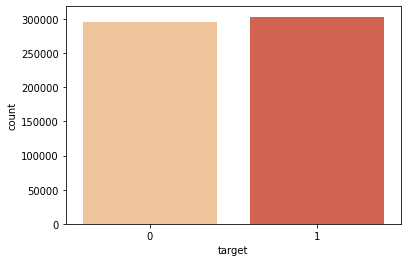

In [7]:
from collections import Counter
print(sorted(Counter(train['target']).items()))
sns.countplot(train['target'],palette='OrRd')

<AxesSubplot:>

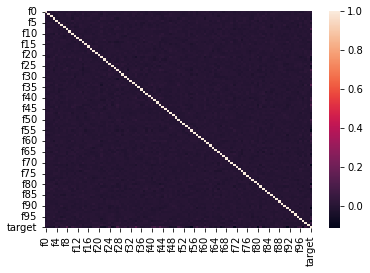

In [8]:
sns.heatmap(train.corr())

<AxesSubplot:>

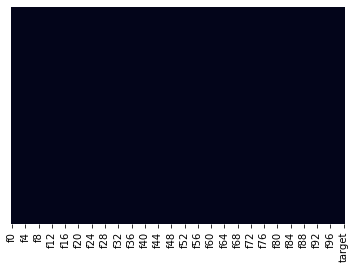

In [9]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False)

In [10]:
train_x=train.drop(['target'],1)
test_x=test

In [11]:
X= train_x
y= train['target']

In [12]:
#dividing the dataset into train and test sets
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=1234)

<a id="section-one"></a>

##  <span style='font-size:22px;'>&#128311;</span>  sampling to reduce training time



In [13]:
x_train2,x_test2,y_train2,y_test2=train_test_split(x_train,y_train,test_size=0.15,random_state=1234)

In [14]:
x_train3,x_test3,y_train3,y_test3=train_test_split(x_train2,y_train2,test_size=0.14,random_state=1234)

In [15]:
x_train4,x_test4,y_train4,y_test4=train_test_split(x_train3,y_train3,test_size=0.15,random_state=1234)

In [16]:
x_train5,x_test5,y_train5,y_test5=train_test_split(x_train4,y_train4,test_size=0.04,random_state=1234)

In [17]:
x_train1,x_test1,y_train1,y_test1=train_test_split(x_train5,y_train5,test_size=0.1,random_state=1234)

In [18]:
print(x_train1.shape)
print(x_test.shape)

(257685, 100)
(120000, 100)


<a id="section-three"></a>

##  <span style='font-size:22px;'>&#8987;</span> Model fitting

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

#libraries for model evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import classification_report

train accuracy: 0.7374662863573743 
 test accuracy: 0.7397083333333333


classification report for logistic regression
              precision    recall  f1-score   support

           0       0.73      0.74      0.73     58399
           1       0.75      0.74      0.74     61601

    accuracy                           0.74    120000
   macro avg       0.74      0.74      0.74    120000
weighted avg       0.74      0.74      0.74    120000



confusion matrix for logistic regression


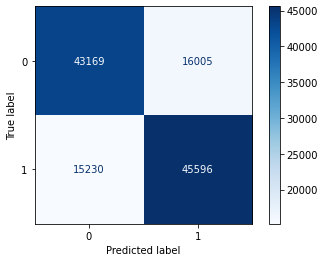

In [20]:
from sklearn.linear_model import RidgeClassifier
rc =RidgeClassifier()
model0=rc.fit(x_train1, y_train1)
print("train accuracy:",model0.score(x_train1, y_train1),"\n","test accuracy:",model0.score(x_test,y_test))
rcpred = rc.predict(x_test)
print("\n")
print("classification report for logistic regression")
print(classification_report(rcpred,y_test))
print("\n")
print("confusion matrix for logistic regression")
displr = plot_confusion_matrix(rc, x_test, y_test,cmap=plt.cm.Blues , values_format='d')

train accuracy: 0.7330151153540175 
 test accuracy: 0.7347833333333333


classification report for logistic regression
              precision    recall  f1-score   support

           0       0.73      0.73      0.73     58488
           1       0.74      0.74      0.74     61512

    accuracy                           0.73    120000
   macro avg       0.73      0.73      0.73    120000
weighted avg       0.73      0.73      0.73    120000



confusion matrix for logistic regression


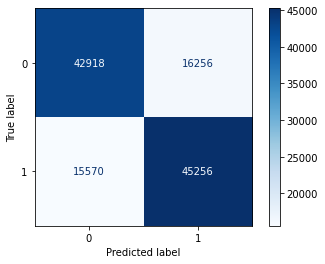

In [21]:
#logistic regression
lr = LogisticRegression(max_iter=10000,penalty='l2')
model1=lr.fit(x_train1, y_train1)
print("train accuracy:",model1.score(x_train1, y_train1),"\n","test accuracy:",model1.score(x_test,y_test))
lrpred = lr.predict(x_test)
print("\n")
print("classification report for logistic regression")
print(classification_report(lrpred,y_test))
print("\n")
print("confusion matrix for logistic regression")
displr = plot_confusion_matrix(lr, x_test, y_test,cmap=plt.cm.Blues , values_format='d')

train accuracy: 0.7374818091856337 
 test accuracy: 0.739725


classification report for linear discriminant analysis
              precision    recall  f1-score   support

           0       0.73      0.74      0.73     58399
           1       0.75      0.74      0.74     61601

    accuracy                           0.74    120000
   macro avg       0.74      0.74      0.74    120000
weighted avg       0.74      0.74      0.74    120000



confusion matrix for linear discriminant analysis


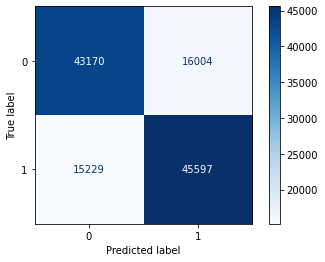

In [22]:
#linear discriminant analysis
lda = LinearDiscriminantAnalysis()
model2=lda.fit(x_train1, y_train1)
print("train accuracy:",model2.score(x_train1, y_train1),"\n","test accuracy:",model2.score(x_test,y_test))

ldapred = lda.predict(x_test)
print("\n")
print("classification report for linear discriminant analysis")
print(classification_report(ldapred,y_test))
print("\n")
print("confusion matrix for linear discriminant analysis")
displr = plot_confusion_matrix(lda, x_test, y_test ,cmap=plt.cm.Blues , values_format='d')

train accuracy: 0.5843413469934222 
 test accuracy: 0.5783916666666666


classification report for linear discriminant analysis
              precision    recall  f1-score   support

           0       0.78      0.55      0.65     83383
           1       0.39      0.64      0.48     36617

    accuracy                           0.58    120000
   macro avg       0.58      0.60      0.56    120000
weighted avg       0.66      0.58      0.59    120000



confusion matrix for linear discriminant analysis


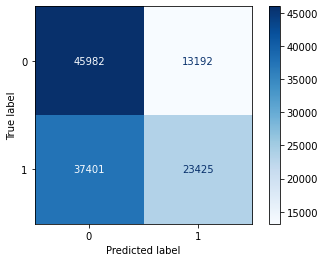

In [23]:
#quadratic discriminant analysis
qda = QuadraticDiscriminantAnalysis()
model3=qda.fit(x_train1, y_train1)
print("train accuracy:",model3.score(x_train1, y_train1),"\n","test accuracy:",model3.score(x_test,y_test))

qdapred = qda.predict(x_test)
print("\n")
print("classification report for linear discriminant analysis")
print(classification_report(qdapred,y_test))
print("\n")
print("confusion matrix for linear discriminant analysis")
displr = plot_confusion_matrix(qda, x_test, y_test ,cmap=plt.cm.Blues , values_format='d')

<center><img src="https://media.giphy.com/media/3jmqIaBE8x86xwbSbD/giphy.gif"></center>

train accuracy: 0.7379474940334129 
 test accuracy: 0.7401916666666667


classification report for voting classifier
              precision    recall  f1-score   support

           0       0.73      0.74      0.73     58405
           1       0.75      0.74      0.75     61595

    accuracy                           0.74    120000
   macro avg       0.74      0.74      0.74    120000
weighted avg       0.74      0.74      0.74    120000



confusion matrix for voting classifier


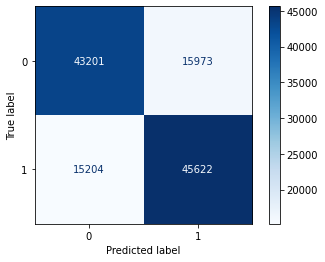

In [24]:
# stacking classifier 
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

estimators = [('rf',make_pipeline(StandardScaler(),LinearDiscriminantAnalysis()) ),('ext', make_pipeline(StandardScaler(),LogisticRegression(max_iter=10000,penalty='l2')))]
sc= StackingClassifier( estimators=estimators)

model5=sc.fit(x_train1, y_train1)
print("train accuracy:",model5.score(x_train1, y_train1),"\n","test accuracy:",model5.score(x_test,y_test))

scpred = sc.predict(x_test)
print("\n")
print("classification report for voting classifier")
print(classification_report(scpred,y_test))
print("\n")
print("confusion matrix for voting classifier")
displr = plot_confusion_matrix(sc, x_test, y_test ,cmap=plt.cm.Blues , values_format='d')

train accuracy: 0.7627956613695015 
 test accuracy: 0.7142333333333334


classification report for extra tree classifier
              precision    recall  f1-score   support

           0       0.70      0.71      0.71     58286
           1       0.73      0.71      0.72     61714

    accuracy                           0.71    120000
   macro avg       0.71      0.71      0.71    120000
weighted avg       0.71      0.71      0.71    120000



confusion matrix for extra tree classifier


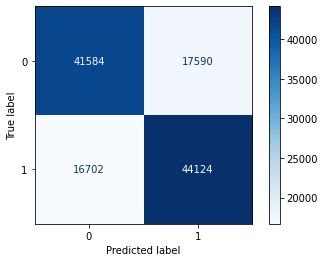

In [25]:
from catboost import CatBoostClassifier

cc = CatBoostClassifier(silent=True )
model6=cc.fit(x_train1, y_train1)
print("train accuracy:",model6.score(x_train1, y_train1),"\n","test accuracy:",model6.score(x_test,y_test))

ccpred = cc.predict(x_test)
print("\n")
print("classification report for extra tree classifier")
print(classification_report(ccpred,y_test))
print("\n")
print("confusion matrix for extra tree classifier")
displr = plot_confusion_matrix(cc, x_test, y_test ,cmap=plt.cm.Blues , values_format='d')

<a id="section-five"></a>

##  <span style='font-size:22px;'>&#9200;</span>  tuning of logistic regression

In [26]:
from sklearn.model_selection import GridSearchCV
LR = LogisticRegression()
LRparam_grid = {
    'C': [ 100,250, 400, 500,1000],
    'penalty': ['l1', 'l2'],
    'max_iter': [200,400,600],
    'solver': ['liblinear']
}
LR_search = GridSearchCV(LR, param_grid=LRparam_grid, refit = True, verbose = 3, cv=3)

# fitting the model for grid search 
LR_search.fit(x_train1 , y_train1)
LR_search.best_params_
# summarize
print('Mean Accuracy: %.3f' % LR_search.best_score_)
print('Config: %s' % LR_search.best_params_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] C=100, max_iter=200, penalty=l1, solver=liblinear ...............


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


[CV]  C=100, max_iter=200, penalty=l1, solver=liblinear, score=0.735, total=  55.8s
[CV] C=100, max_iter=200, penalty=l1, solver=liblinear ...............


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   55.8s remaining:    0.0s


[CV]  C=100, max_iter=200, penalty=l1, solver=liblinear, score=0.737, total=  56.5s
[CV] C=100, max_iter=200, penalty=l1, solver=liblinear ...............


[Parallel(n_jobs=1)]: Done   2 out of   2 | elapsed:  1.9min remaining:    0.0s


[CV]  C=100, max_iter=200, penalty=l1, solver=liblinear, score=0.737, total=  59.5s
[CV] C=100, max_iter=200, penalty=l2, solver=liblinear ...............
[CV]  C=100, max_iter=200, penalty=l2, solver=liblinear, score=0.736, total=  44.9s
[CV] C=100, max_iter=200, penalty=l2, solver=liblinear ...............
[CV]  C=100, max_iter=200, penalty=l2, solver=liblinear, score=0.737, total=  37.3s
[CV] C=100, max_iter=200, penalty=l2, solver=liblinear ...............
[CV]  C=100, max_iter=200, penalty=l2, solver=liblinear, score=0.737, total=  43.2s
[CV] C=100, max_iter=400, penalty=l1, solver=liblinear ...............
[CV]  C=100, max_iter=400, penalty=l1, solver=liblinear, score=0.735, total=  58.6s
[CV] C=100, max_iter=400, penalty=l1, solver=liblinear ...............
[CV]  C=100, max_iter=400, penalty=l1, solver=liblinear, score=0.737, total= 1.3min
[CV] C=100, max_iter=400, penalty=l1, solver=liblinear ...............
[CV]  C=100, max_iter=400, penalty=l1, solver=liblinear, score=0.737, 

[Parallel(n_jobs=1)]: Done  90 out of  90 | elapsed: 75.3min finished


Mean Accuracy: 0.737
Config: {'C': 400, 'max_iter': 200, 'penalty': 'l2', 'solver': 'liblinear'}


train accuracy: 0.7380251081747095 
 test accuracy: 0.74015


classification report for logistic regression
              precision    recall  f1-score   support

           0       0.73      0.74      0.73     58372
           1       0.75      0.74      0.75     61628

    accuracy                           0.74    120000
   macro avg       0.74      0.74      0.74    120000
weighted avg       0.74      0.74      0.74    120000



confusion matrix for logistic regression


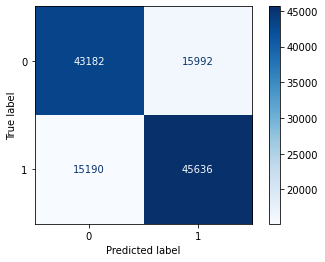

In [27]:
#logistic regression
lr = LogisticRegression(max_iter=600,penalty='l1',C=400,solver='liblinear')
model7=lr.fit(x_train1, y_train1)
print("train accuracy:",model7.score(x_train1, y_train1),"\n","test accuracy:",model7.score(x_test,y_test))
lrpred = lr.predict(x_test)
print("\n")
print("classification report for logistic regression")
print(classification_report(lrpred,y_test))
print("\n")
print("confusion matrix for logistic regression")
displr = plot_confusion_matrix(lr, x_test, y_test,cmap=plt.cm.Blues , values_format='d')

<font size="4">Let's see stacking classifier with tuned logistic and linear discriminant analysis models.</font>

train accuracy: 0.7379436133263481 
 test accuracy: 0.7401833333333333


classification report for voting classifier
              precision    recall  f1-score   support

           0       0.73      0.74      0.73     58404
           1       0.75      0.74      0.75     61596

    accuracy                           0.74    120000
   macro avg       0.74      0.74      0.74    120000
weighted avg       0.74      0.74      0.74    120000



confusion matrix for voting classifier


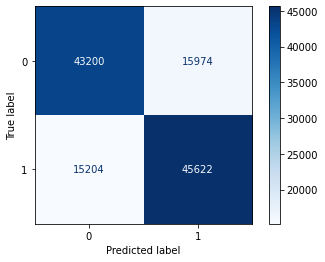

In [28]:
# stacking classifier 
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

estimators = [('lda',make_pipeline(StandardScaler(),LinearDiscriminantAnalysis() )),('lr', make_pipeline(StandardScaler(),LogisticRegression(max_iter=600,penalty='l1',C=400, solver='liblinear')))]
scfinal= StackingClassifier( estimators=estimators)

model8=scfinal.fit(x_train1, y_train1)
print("train accuracy:",model8.score(x_train1, y_train1),"\n","test accuracy:",model8.score(x_test,y_test))

scpred = scfinal.predict(x_test)
print("\n")
print("classification report for voting classifier")
print(classification_report(scpred,y_test))
print("\n")
print("confusion matrix for voting classifier")
displr = plot_confusion_matrix(scfinal, x_test, y_test ,cmap=plt.cm.Blues , values_format='d')

In [29]:
predictions=model8.predict_proba(test)

In [30]:
df_submission = pd.read_csv('/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv')
df_submission['target']=predictions[:,1]
df_submission.to_csv('submission.csv',index=False)

<a id="section-five"></a>

##  <span style='font-size:22px;'>&#128142;</span>  Results

<font size="4" color="black"> In this notebook I used a subset of the training sample randomly to fit the models. It gives better results than my<a href="https://www.kaggle.com/sisharaneranjana/model-fitting-with-normal-quantile-transformation"> previous notebook.</a> In that also <span style="color:red;">linear models and catboost classifiers</span> had the best performance and tree based models tend to overfitting. Here logistic regression model and the linear discriminant analysis was tuned using a grid search. The highest accuracy achieved is <span style="color:red;">74.01%</span>which is a increase of 3% than previous effort.</font>


<center><img src="https://media.giphy.com/media/j1Xyt3DHfJcmk/giphy.gif"></center>

<font size="4"><b> Any suggestions,questions or feedback regarding this notebook are highly appreciated. THANK YOU <span style='font-size:22px;'>&#128522;</span> <b></font>